In [10]:
import numpy as np
import struct
import random

from array import array
from os.path import join

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from openTSNE.affinity import PerplexityBasedNN
from scipy.sparse import csr_matrix
from scipy.io import mmwrite

import scipy.sparse

import os

In [2]:
#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath, test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)        

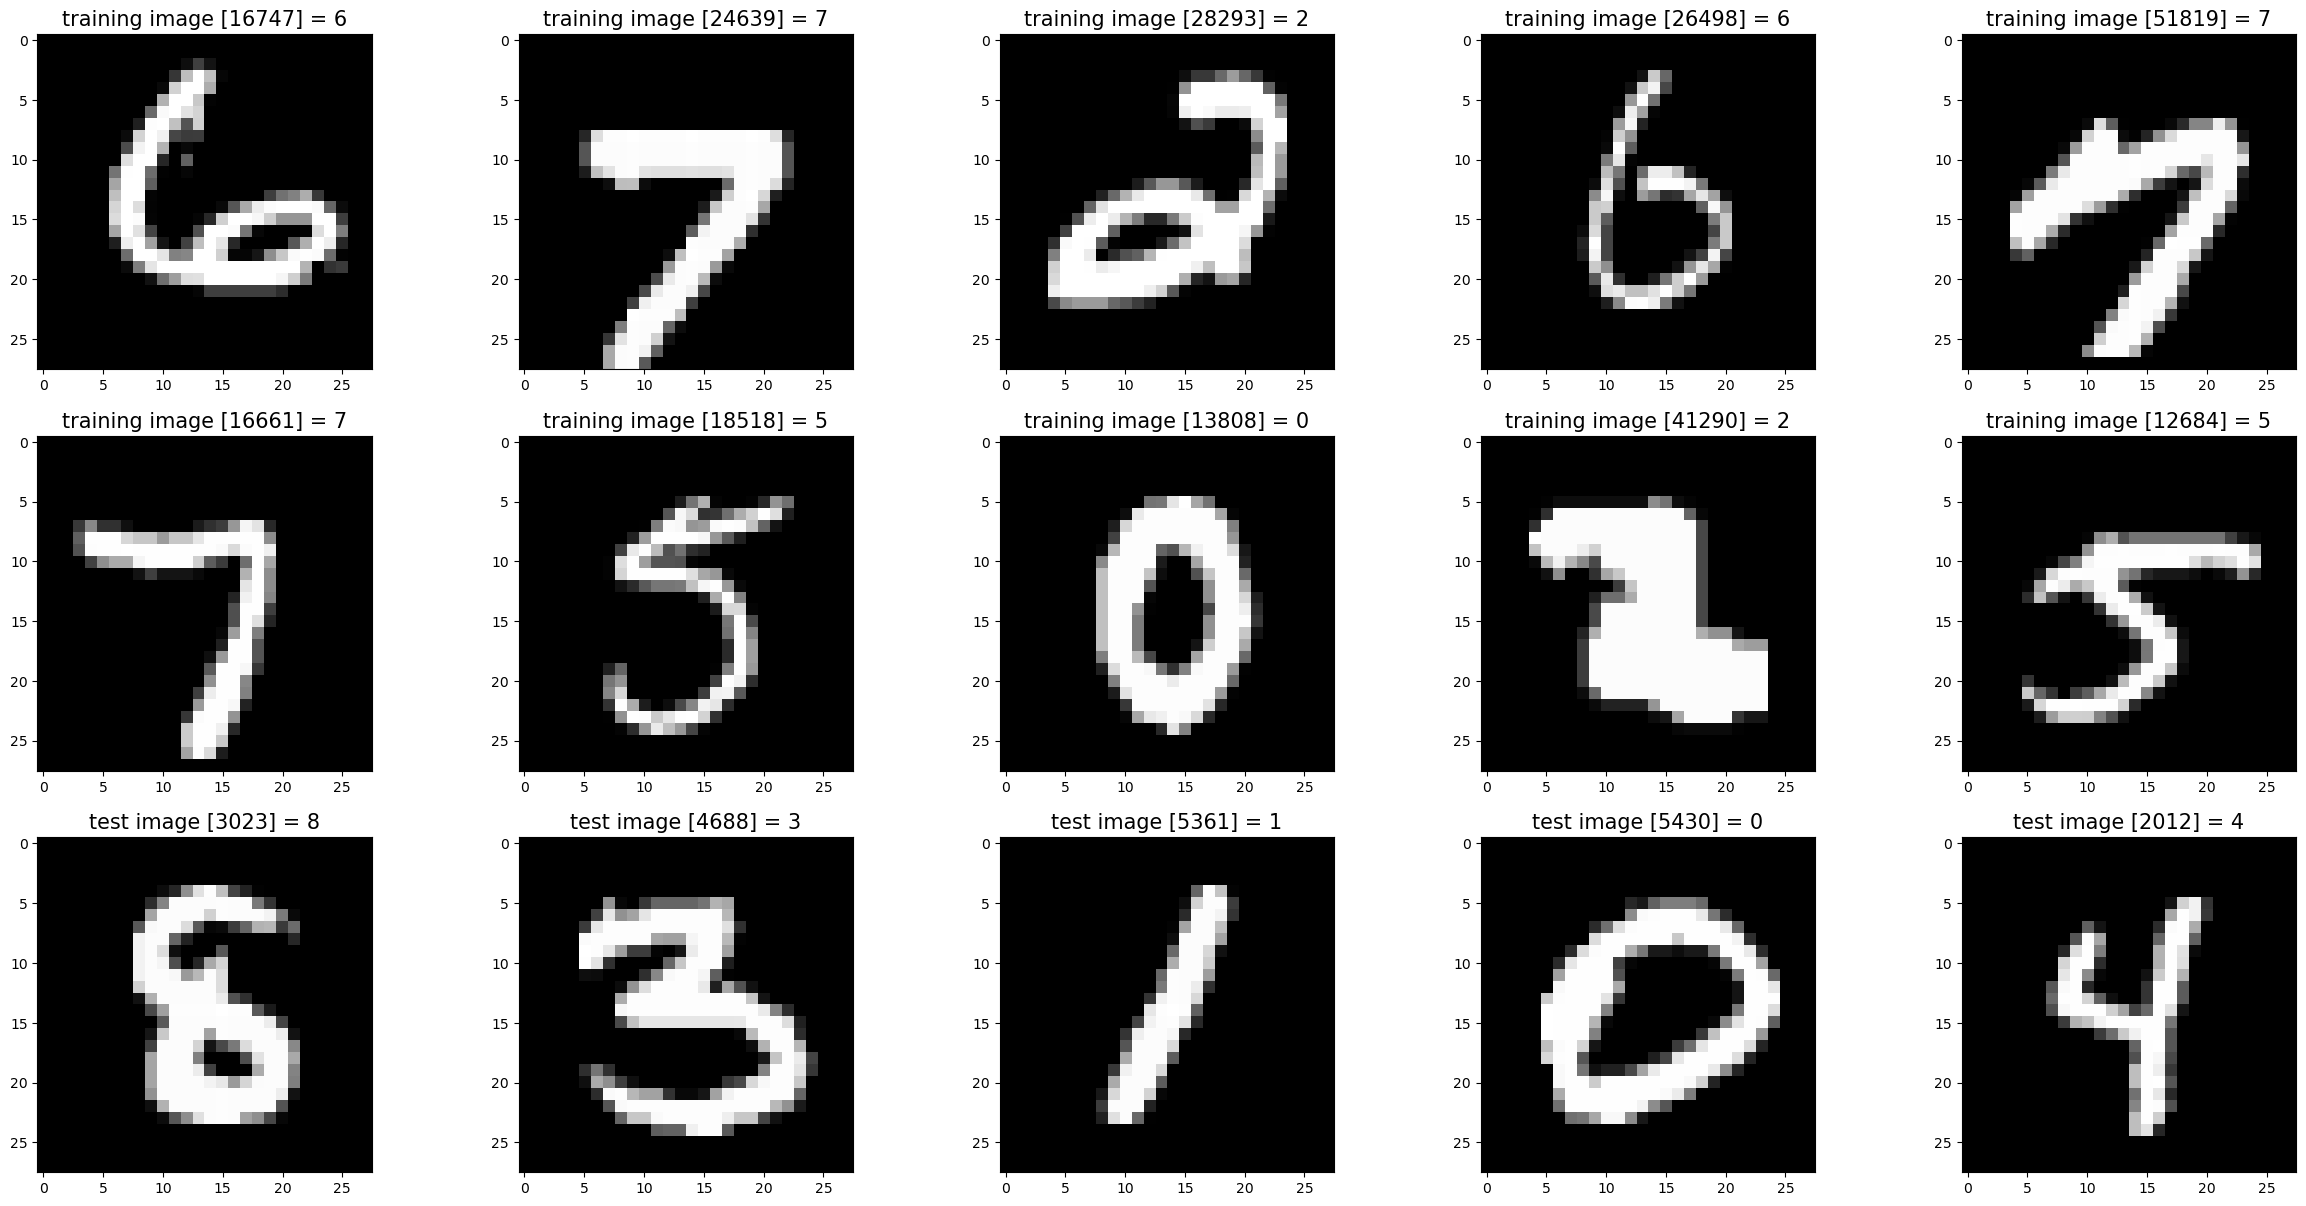

In [4]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline



#
# Set file paths based on added MNIST Datasets
#
#input_path = './input'
input_path = './TSNEdataInput'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images.idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels.idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images.idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [12]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

# set parameters
amount = 1000
perp = 30

# select random data
random_indices = np.random.choice(x_train.shape[0], size=amount, replace=False)
x_train_selection = x_train[random_indices]
y_train_selection = y_train[random_indices]
print("selected data: ", x_train_selection.shape)
print("selected labels: ", y_train_selection.shape)

# flatten the dimensions of the image matrix
x_train_selection_flat = x_train_selection.reshape(amount, -1)

# reduce the dimesnions of the image
pca = PCA(n_components=50)
x_train_selection_flat_reduced = pca.fit_transform(x_train_selection_flat)
print("selected data reduced dim: ", x_train_selection_flat_reduced.shape)

# create tsne and obtain the P matrix
affinities = PerplexityBasedNN(x_train_selection_flat_reduced, perplexity=perp)
P_matrix = affinities.P

# store P matrix on disk
print(type(P_matrix))
print(P_matrix)
file_name_P = os.path.join("data", f"P_matrix_amount{amount}_perp{perp}.mtx")
#file_name_P = "P_matrix_amount" +  str(amount) + "_perp" + str(perp) + ".mtx"
mmwrite(file_name_P, P_matrix)

# store labels on disk
print(type(y_train_selection))
print(y_train_selection)
file_name_L = os.path.join("data", f"label_amount{amount}_perp{perp}.bin")
#file_name_L = "label_amount" +  str(amount) + "_perp" + str(perp) + ".bin"
with open(file_name_L, 'wb') as f:
    f.write(y_train_selection.tobytes())

selected data:  (1000, 28, 28)
selected labels:  (1000,)
selected data reduced dim:  (1000, 50)
<class 'scipy.sparse._csr.csr_matrix'>
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 122920 stored elements and shape (1000, 1000)>
  Coords	Values
  (0, 934)	1.0693754227595597e-06
  (0, 914)	5.02758401467003e-07
  (0, 806)	1.0353799456880835e-06
  (0, 743)	3.2181950631160464e-07
  (0, 553)	1.9947571474596628e-06
  (0, 516)	2.9331093018548486e-06
  (0, 466)	5.38580493289376e-07
  (0, 370)	1.665942629133513e-06
  (0, 289)	7.372938608219919e-07
  (0, 199)	1.1256202740400885e-06
  (0, 185)	4.5791011325311763e-07
  (0, 156)	5.002943915025273e-07
  (0, 825)	3.077407433367989e-06
  (0, 550)	6.041111893539239e-07
  (0, 216)	6.090414229531719e-07
  (0, 150)	1.002639767706156e-06
  (0, 876)	6.117707079917214e-07
  (0, 768)	6.1605587805135e-07
  (0, 809)	6.184358264153922e-07
  (0, 364)	6.314774536658369e-07
  (0, 564)	6.340081204171968e-07
  (0, 808)	6.540046559865354e-07
  (0, 314)	

In [6]:
# Initialize t-SNE
#tsne = TSNE(n_components=2, random_state=42)  # 2D visualization
tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, n_iter=3000, random_state=42)


# Fit and transform the data
X_embedded = tsne.fit_transform(x_train_selection_flat_reduced)
print("embedding dim: ", X_embedded.shape)  # Should be (n_samples, 2)

/home/lucas/miniconda3/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


embedding dim:  (2000, 2)


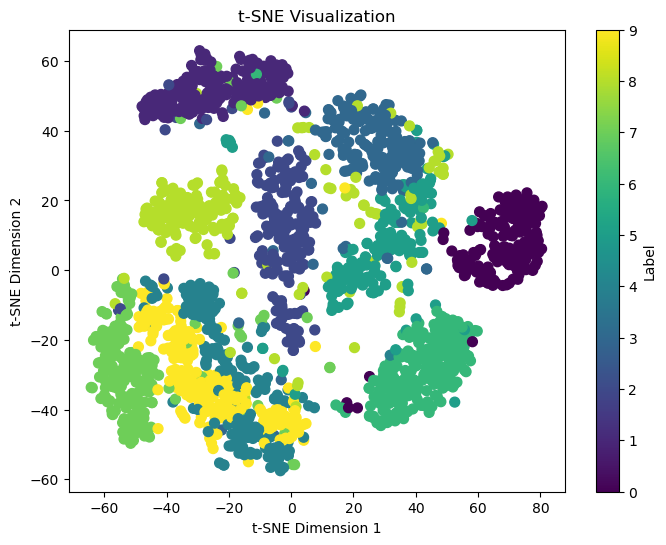

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_train_selection, cmap='viridis', s=50)
plt.colorbar(label='Label')
plt.title('t-SNE Visualization')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()